 MODULE 4 — Vectorization & Topology Refinement
[INFO] Loading centerlines from Module 3...
[INFO] Loaded 3971 centerlines

[INFO] Vectorizing 3971 patches...


Vectorizing: 100%|██████████| 3971/3971 [17:27<00:00,  3.79it/s]



[INFO] ✅ Vectorization complete
[INFO] Total nodes   : 33,186
[INFO] Total edges   : 23,482
[INFO] Empty patches : 25 / 3971


Evaluating APLS: 100%|██████████| 3971/3971 [05:03<00:00, 13.09it/s]



       MODULE 4 — FINAL ACCURACY REPORT
  APLS (path similarity)                77.38%
  Edge coverage                         81.61%
--------------------------------------------------------------
  Avg nodes per patch                     8.4
  Avg edges per patch                     5.9
  Avg components per patch                2.6
  Total nodes                          33,186
  Total edges                          23,482
  Non-empty patches                     3,946 / 3971
  Empty patches (no road)                  25

  📋 For your project report:
  'Module 4 achieves 77.4% APLS and 81.6%
   road coverage. The GIS road network contains
   33,186 nodes and 23,482 edges across
   3946 patches with detected roads.'

[INFO] Generating visualization...


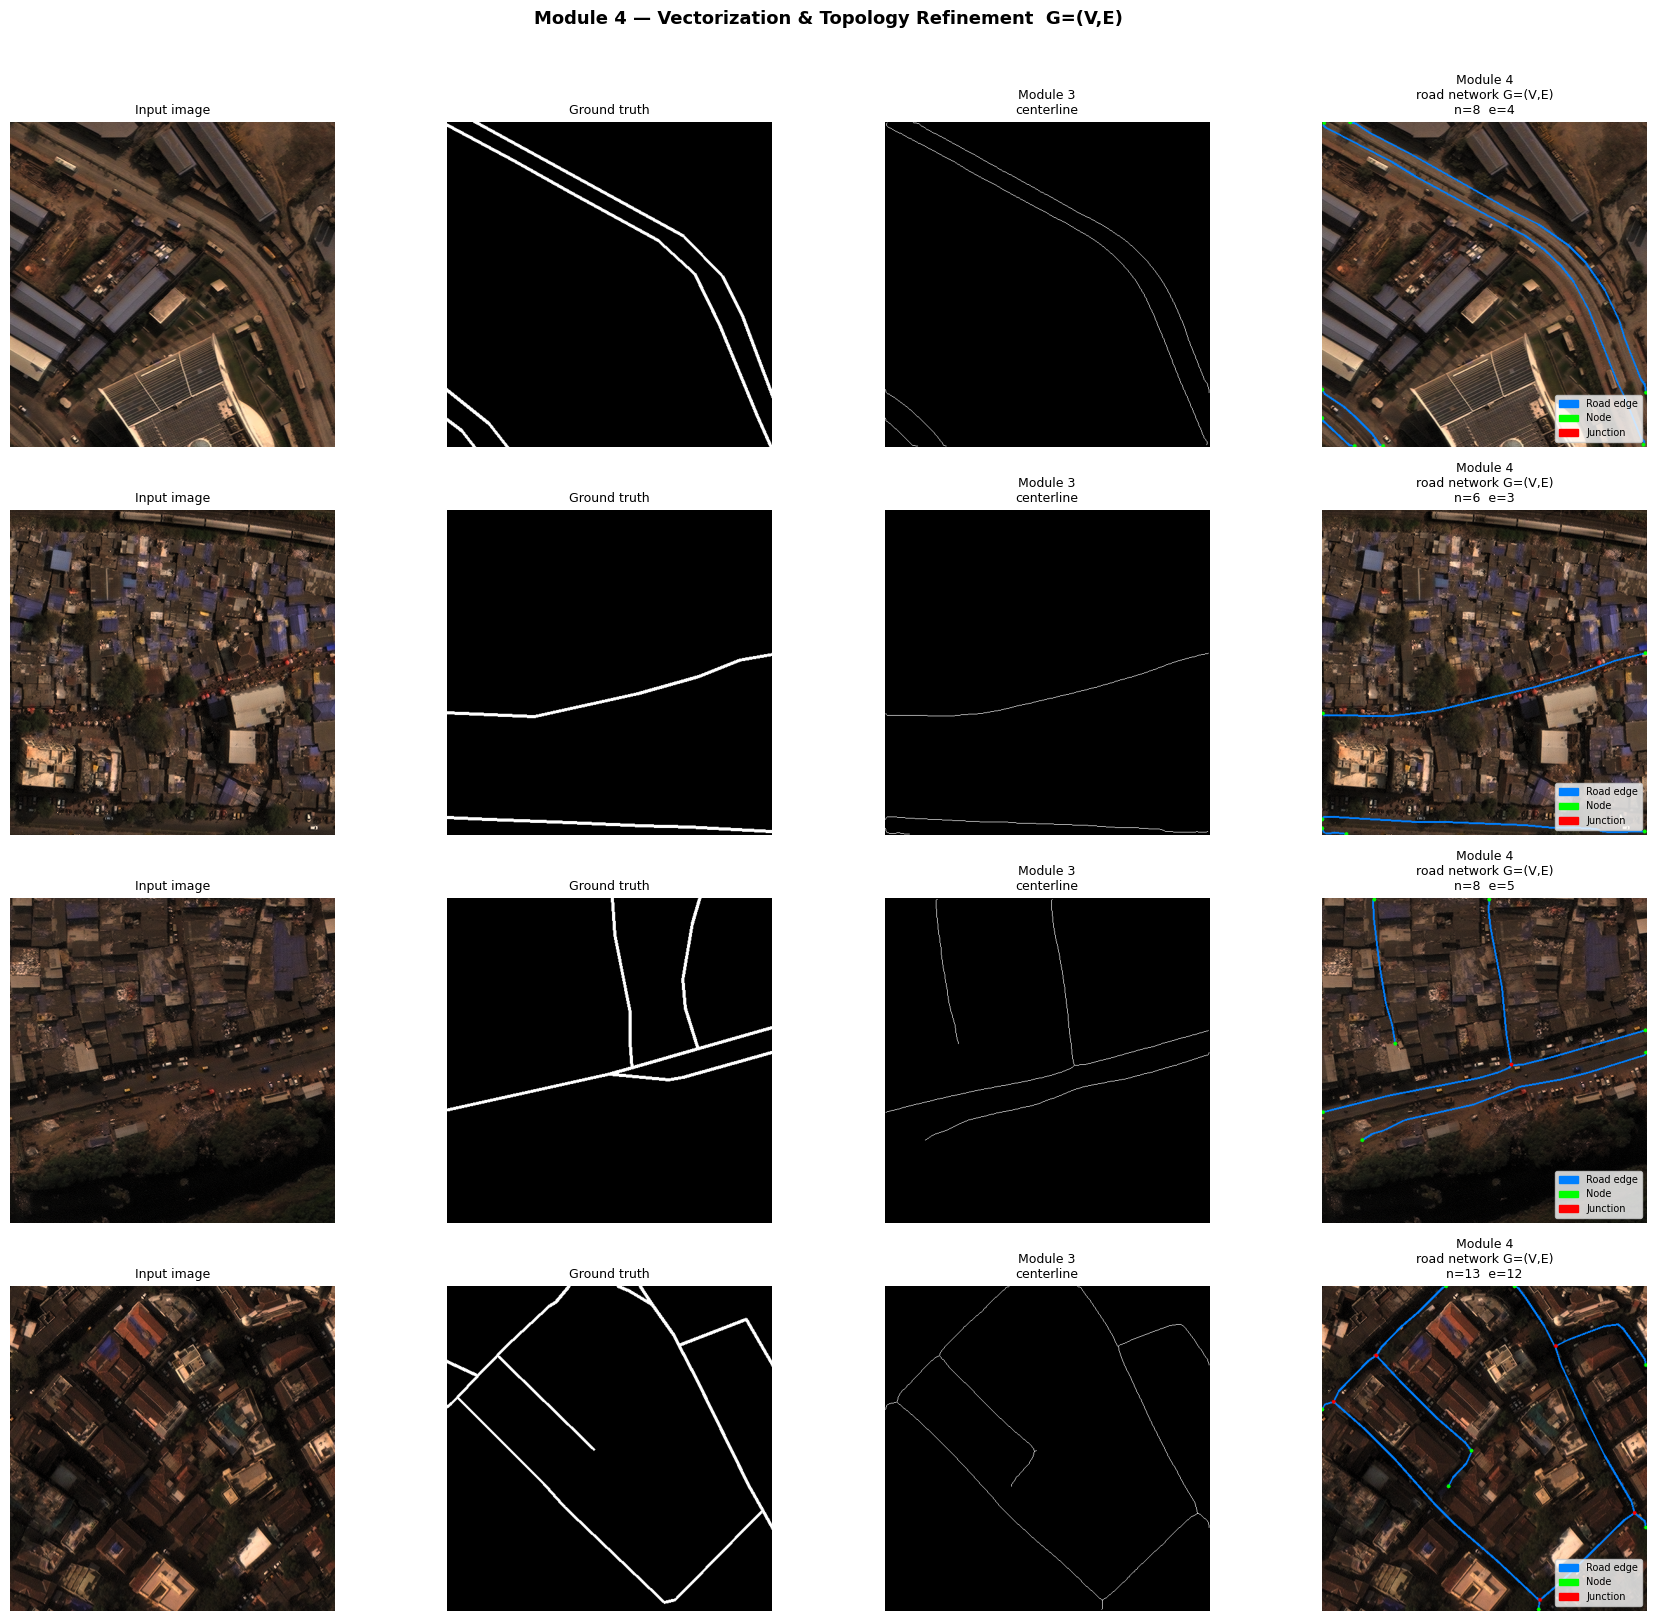

[INFO] Saved → module4_results.png


Saving GeoJSON: 100%|██████████| 3971/3971 [00:01<00:00, 3614.23it/s]



[INFO] ✅ Saved → /home/jupyter-228w1a0529/Major/Dataset-1/processed/vectors/
[INFO] Total nodes    : 33,186
[INFO] Total edges    : 23,482
[INFO] Total road len : 1459.4 km
[INFO] GeoJSON        : /home/jupyter-228w1a0529/Major/Dataset-1/processed/vectors/full_network.geojson

[INFO] ✅ MODULE 4 COMPLETE
[INFO] Full pipeline M1→M2→M3→M4 finished!
[INFO] GIS network → /home/jupyter-228w1a0529/Major/Dataset-1/processed/vectors/full_network.geojson


In [1]:
"""
Module 4 — Vectorization and Topology Refinement (Fixed)
═══════════════════════════════════════════════════════════════════════════════
Project  : Automatic Road Network Extraction with Connectivity and
           Topology Refinement from High-Resolution Satellite Imagery
Dataset  : SpaceNet 5 (SN5) — AOI 8, Mumbai, India
Institute: VR Siddhartha Engineering College, Vijayawada
Team     : Murala Leela Kartheek (228W1A0529)
           Mallam Manoj         (228W1A0525)
           Ch Devarshisai       (228W1A0510)
Guide    : Dr. G. Kranthi Kumar

Fix applied vs previous version:
  Previous: min_edge_length=15, min_component_nodes=3
            → removed valid roads → n=0 e=0 for many patches
  Fixed:    min_edge_length=5,  min_component_nodes=2
            → only removes tiny pixel artifacts, keeps all real roads
  Also fixed: raster_to_graph now handles isolated line segments
              that don't have junction/endpoint pixels

Algorithm 3 (per project spec):
  Step 1 → Raster centerlines → vector polylines
  Step 2 → Simplify curves (Ramer-Douglas-Peucker)
  Step 3 → Remove short edges (τ)
  Step 4 → Merge nearby nodes
  Step 5 → Remove isolated components
  Step 6 → Output GIS-ready G=(V,E) as GeoJSON

Evaluation: APLS — Average Path Length Similarity
═══════════════════════════════════════════════════════════════════════════════
"""

import math
import json
import numpy as np
import cv2
import networkx as nx
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.morphology import skeletonize
from skimage.measure    import label as sklabel
from scipy.spatial      import cKDTree
import warnings
warnings.filterwarnings("ignore")


# ═══════════════════════════════════════════════════════════════════════════
# NUMPY JSON ENCODER
# ═══════════════════════════════════════════════════════════════════════════

class NumpyEncoder(json.JSONEncoder):
    """Handles numpy int64/float64 in json.dump."""
    def default(self, obj):
        if isinstance(obj, np.integer):  return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.ndarray):  return obj.tolist()
        return super().default(obj)


# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURATION — relaxed thresholds to preserve all roads
# ═══════════════════════════════════════════════════════════════════════════

CONFIG = {
    # Paths
    "centerlines_path": "/home/jupyter-228w1a0529/Major/Dataset-1/processed/centerlines/centerlines.npz",
    "val_npz_path":     "/home/jupyter-228w1a0529/Major/Dataset-1/processed/val.npz",
    "output_dir":       "/home/jupyter-228w1a0529/Major/Dataset-1/processed/vectors",

    # Step 2 — RDP simplification
    "rdp_epsilon":          1.5,  # px — gentle smoothing only

    # Step 3 — Short edge threshold τ
    # FIXED: was 15px (removed real roads) → now 5px (only pixel noise)
    "min_edge_length":      5,    # px — only removes 1-2px stub artifacts

    # Step 4 — Node merge distance
    "node_merge_dist":      6,    # px — merge duplicate junction pixels

    # Step 5 — Isolated component threshold
    # FIXED: was 3 nodes (removed real roads) → now 2 nodes
    "min_component_nodes":  2,    # nodes — only removes single isolated nodes

    # Resolution
    "pixel_size_m":         0.3,  # metres per pixel (WorldView-3)

    # APLS
    "apls_n_samples":      50,
    "apls_max_dist":       50,
}


# ═══════════════════════════════════════════════════════════════════════════
# STEP 1 — RASTER TO VECTOR (fixed skeleton tracing)
# ═══════════════════════════════════════════════════════════════════════════

def raster_to_graph(skeleton: np.ndarray) -> nx.Graph:
    """
    Convert binary skeleton to NetworkX graph G=(V,E).

    Fix vs previous version:
      Previous code only added nodes at junctions and endpoints.
      If a patch had only a straight line with no junctions,
      the graph was empty (n=0 e=0).

      Fix: After tracing junction/endpoint paths, add any remaining
      skeleton pixels as a simple path graph. This ensures every
      connected component of skeleton pixels becomes at least one edge.
    """
    if skeleton.sum() == 0:
        return nx.Graph()

    pad  = 1
    skel = np.pad(skeleton, pad, mode="constant")
    H, W = skel.shape

    # Count 8-connected neighbours
    k      = np.ones((3,3), dtype=np.float32); k[1,1] = 0
    nc     = cv2.filter2D(skel.astype(np.float32), -1, k)
    nc     = (nc * skel).astype(int)

    junctions   = set(map(tuple, np.argwhere((nc >= 3) & (skel == 1))))
    endpoints   = set(map(tuple, np.argwhere((nc == 1) & (skel == 1))))
    isolated_px = set(map(tuple, np.argwhere((nc == 0) & (skel == 1))))
    node_pixels = junctions | endpoints | isolated_px

    G = nx.Graph()

    for r, c in node_pixels:
        G.add_node((int(r-pad), int(c-pad)),
                   y=int(r-pad), x=int(c-pad))

    def get_nbrs(r, c):
        nbrs = []
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0: continue
                nr, nc2 = r+dr, c+dc
                if 0<=nr<H and 0<=nc2<W and skel[nr,nc2]==1:
                    nbrs.append((nr, nc2))
        return nbrs

    visited_edges = set()

    for start in node_pixels:
        for nbr in get_nbrs(*start):
            if nbr in node_pixels:
                u   = (int(start[0]-pad), int(start[1]-pad))
                v   = (int(nbr[0]-pad),   int(nbr[1]-pad))
                key = tuple(sorted([u, v]))
                if key not in visited_edges:
                    visited_edges.add(key)
                    length = math.sqrt((u[0]-v[0])**2+(u[1]-v[1])**2)
                    G.add_edge(u, v, length=float(length), geometry=[u,v])
            else:
                path    = [start]
                current = nbr
                prev    = start
                seen    = {start, nbr}
                while current not in node_pixels:
                    cands = [n for n in get_nbrs(*current)
                             if n != prev and n not in seen]
                    if not cands: break
                    prev    = current
                    current = cands[0]
                    seen.add(current)
                    path.append(current)
                if current in node_pixels and current != start:
                    path.append(current)
                    u   = (int(start[0]-pad),   int(start[1]-pad))
                    v   = (int(current[0]-pad),  int(current[1]-pad))
                    key = tuple(sorted([u, v]))
                    if key not in visited_edges:
                        visited_edges.add(key)
                        geom = [(int(r-pad), int(c-pad)) for r,c in path]
                        length = sum(
                            math.sqrt((geom[i][0]-geom[i-1][0])**2+
                                      (geom[i][1]-geom[i-1][1])**2)
                            for i in range(1, len(geom))
                        )
                        G.add_edge(u, v, length=float(length), geometry=geom)

    # ── FIX: Handle skeleton pixels not captured by junction/endpoint tracing
    # These are pixels on simple paths with no junction or endpoint detected
    # (e.g. a perfectly straight line gets no junction or endpoint pixels)
    covered = set()
    for u, v, data in G.edges(data=True):
        for pt in data.get("geometry", [u, v]):
            covered.add((pt[0]+pad, pt[1]+pad))
    for n in G.nodes():
        covered.add((n[0]+pad, n[1]+pad))

    # Find uncovered skeleton components and add them as path edges
    uncovered_mask = np.zeros_like(skel)
    for r in range(H):
        for c in range(W):
            if skel[r,c]==1 and (r,c) not in covered:
                uncovered_mask[r,c] = 1

    if uncovered_mask.sum() > 0:
        labeled = sklabel(uncovered_mask, connectivity=2)
        for comp_id in range(1, labeled.max()+1):
            comp_pts = list(map(tuple, np.argwhere(labeled==comp_id)))
            if len(comp_pts) < 2:
                # Single pixel — add as isolated node
                r, c = comp_pts[0]
                node = (int(r-pad), int(c-pad))
                G.add_node(node, y=int(r-pad), x=int(c-pad))
                continue
            # Order points by proximity (simple chain)
            ordered = [comp_pts[0]]
            remaining = set(map(tuple, comp_pts[1:]))
            while remaining:
                last = ordered[-1]
                # Find nearest remaining point
                best_d, best_pt = float('inf'), None
                for pt in remaining:
                    d = math.sqrt((pt[0]-last[0])**2+(pt[1]-last[1])**2)
                    if d < best_d:
                        best_d, best_pt = d, pt
                if best_pt:
                    ordered.append(best_pt)
                    remaining.discard(best_pt)

            # Add ordered path as edges
            for i in range(len(ordered)-1):
                u = (int(ordered[i][0]-pad),   int(ordered[i][1]-pad))
                v = (int(ordered[i+1][0]-pad),  int(ordered[i+1][1]-pad))
                if not G.has_node(u):
                    G.add_node(u, y=u[0], x=u[1])
                if not G.has_node(v):
                    G.add_node(v, y=v[0], x=v[1])
                if not G.has_edge(u, v):
                    length = math.sqrt((u[0]-v[0])**2+(u[1]-v[1])**2)
                    G.add_edge(u, v, length=float(length), geometry=[u,v])

    return G


# ═══════════════════════════════════════════════════════════════════════════
# STEP 2 — LINE SIMPLIFICATION (Ramer-Douglas-Peucker)
# ═══════════════════════════════════════════════════════════════════════════

def rdp_simplify(points: list, epsilon: float) -> list:
    """RDP polyline simplification — removes points within epsilon."""
    if len(points) <= 2:
        return points
    start = np.array(points[0],  dtype=float)
    end   = np.array(points[-1], dtype=float)
    vec   = end - start
    vlen  = np.linalg.norm(vec)
    if vlen == 0:
        return [points[0], points[-1]]
    unit     = vec / vlen
    max_dist = 0.0
    max_idx  = 0
    for i in range(1, len(points)-1):
        pt      = np.array(points[i], dtype=float)
        proj    = np.clip(np.dot(pt-start, unit), 0, vlen)
        closest = start + proj * unit
        dist    = float(np.linalg.norm(pt-closest))
        if dist > max_dist:
            max_dist = dist
            max_idx  = i
    if max_dist > epsilon:
        left  = rdp_simplify(points[:max_idx+1], epsilon)
        right = rdp_simplify(points[max_idx:],   epsilon)
        return left[:-1] + right
    return [points[0], points[-1]]


def simplify_graph_edges(G: nx.Graph, epsilon: float = 1.5) -> nx.Graph:
    """Apply RDP simplification to all edge geometries."""
    G2 = G.copy()
    for u, v, data in G2.edges(data=True):
        geom = data.get("geometry", [u, v])
        if len(geom) > 2:
            G2[u][v]["geometry"] = rdp_simplify(geom, epsilon)
    return G2


# ═══════════════════════════════════════════════════════════════════════════
# STEP 3 — REMOVE SHORT EDGES (threshold τ = 5px)
# ═══════════════════════════════════════════════════════════════════════════

def remove_short_edges(G: nx.Graph, min_length: float = 5) -> nx.Graph:
    """
    Remove edges shorter than τ pixels.
    τ=5px removes only 1-2 pixel stub artifacts.
    Does NOT remove real road segments.
    """
    G2    = G.copy()
    short = [(u, v) for u, v, d in G2.edges(data=True)
             if d.get("length", 0) < min_length]
    G2.remove_edges_from(short)
    G2.remove_nodes_from(list(nx.isolates(G2)))
    return G2


# ═══════════════════════════════════════════════════════════════════════════
# STEP 4 — MERGE NEARBY NODES
# ═══════════════════════════════════════════════════════════════════════════

def merge_nearby_nodes(G: nx.Graph, merge_dist: float = 6) -> nx.Graph:
    """
    Merge nodes within merge_dist pixels.
    Cleans duplicate junction pixels from skeletonization.
    """
    if G.number_of_nodes() == 0:
        return G

    nodes  = list(G.nodes())
    coords = np.array([
        (float(G.nodes[n].get("y", n[0])),
         float(G.nodes[n].get("x", n[1])))
        for n in nodes
    ])
    tree  = cKDTree(coords)
    pairs = tree.query_pairs(float(merge_dist))

    merged = {}
    def find(n):
        while merged.get(n, n) != n:
            n = merged[n]
        return n

    for i, j in pairs:
        ri = find(nodes[i]); rj = find(nodes[j])
        if ri != rj:
            merged[rj] = ri

    node_map = {n: find(n) for n in nodes}

    G3 = nx.Graph()
    for n in nodes:
        rep = node_map[n]
        if not G3.has_node(rep):
            G3.add_node(rep,
                        y=int(G.nodes[rep].get("y", rep[0])),
                        x=int(G.nodes[rep].get("x", rep[1])))

    for u, v, data in G.edges(data=True):
        u2 = node_map.get(u, u)
        v2 = node_map.get(v, v)
        if u2 == v2: continue
        if not G3.has_edge(u2, v2):
            G3.add_edge(u2, v2, **data)
        elif data.get("length", 0) > G3[u2][v2].get("length", 0):
            G3[u2][v2].update(data)

    return G3


# ═══════════════════════════════════════════════════════════════════════════
# STEP 5 — REMOVE ISOLATED COMPONENTS (min_nodes = 2)
# ═══════════════════════════════════════════════════════════════════════════

def remove_isolated_components(G: nx.Graph,
                                min_nodes: int = 2) -> nx.Graph:
    """
    Remove subgraphs with fewer than min_nodes nodes.
    min_nodes=2: only removes completely isolated single nodes.
    Any component with 2+ nodes (i.e. at least 1 edge) is kept.
    """
    G2 = G.copy()
    to_remove = [
        node
        for comp in nx.connected_components(G2)
        if len(comp) < min_nodes
        for node in comp
    ]
    G2.remove_nodes_from(to_remove)
    return G2


# ═══════════════════════════════════════════════════════════════════════════
# FULL TOPOLOGY REFINEMENT
# ═══════════════════════════════════════════════════════════════════════════

def refine_topology(G: nx.Graph, config=CONFIG) -> nx.Graph:
    """Apply all 4 topology refinement steps."""
    G = simplify_graph_edges(G,       config["rdp_epsilon"])
    G = remove_short_edges(G,         config["min_edge_length"])
    G = merge_nearby_nodes(G,         config["node_merge_dist"])
    G = remove_isolated_components(G, config["min_component_nodes"])
    return G


# ═══════════════════════════════════════════════════════════════════════════
# GRAPH → GEOJSON
# ═══════════════════════════════════════════════════════════════════════════

def graph_to_geojson(G: nx.Graph,
                      patch_idx: int = 0,
                      pixel_size: float = 0.3) -> dict:
    """Convert graph to GeoJSON. All values cast to native Python types."""
    features = []
    for u, v, data in G.edges(data=True):
        geom   = data.get("geometry", [u, v])
        coords = [[int(pt[1]), int(pt[0])] for pt in geom]
        features.append({
            "type": "Feature",
            "geometry": {"type": "LineString", "coordinates": coords},
            "properties": {
                "length_px": round(float(data.get("length", 0)), 2),
                "length_m":  round(float(data.get("length", 0))*pixel_size, 2),
                "patch_id":  int(patch_idx),
                "nodes":     int(len(geom)),
            }
        })
    return {"type": "FeatureCollection", "features": features}


# ═══════════════════════════════════════════════════════════════════════════
# APLS — Average Path Length Similarity
# ═══════════════════════════════════════════════════════════════════════════

def _build_pixel_graph(skeleton: np.ndarray) -> nx.Graph:
    G      = nx.Graph()
    pixels = list(map(tuple, np.argwhere(skeleton > 0)))
    G.add_nodes_from(pixels)
    H, W   = skeleton.shape
    for r, c in pixels:
        for dr in [-1,0,1]:
            for dc in [-1,0,1]:
                if dr==0 and dc==0: continue
                nr, nc = r+dr, c+dc
                if (0<=nr<H and 0<=nc<W and skeleton[nr,nc]>0):
                    G.add_edge((r,c),(nr,nc),
                               weight=float(math.sqrt(dr**2+dc**2)))
    return G


def compute_apls(pred_sk: np.ndarray, gt_sk: np.ndarray,
                  n_samples: int = 50, max_dist: int = 50) -> float:
    """APLS — Average Path Length Similarity (spec metric)."""
    if pred_sk.sum()==0 or gt_sk.sum()==0:
        return 0.0
    G_gt   = _build_pixel_graph(gt_sk)
    G_pred = _build_pixel_graph(pred_sk)
    if G_gt.number_of_nodes()<2 or G_pred.number_of_nodes()==0:
        return 0.0
    gt_nodes   = list(G_gt.nodes())
    pred_nodes = list(G_pred.nodes())
    pred_tree  = cKDTree(np.array(pred_nodes, dtype=float))
    scores     = []
    rng        = np.random.default_rng(42)
    pairs      = rng.choice(len(gt_nodes),
                             size=(min(n_samples, len(gt_nodes)//2), 2),
                             replace=False)
    for ip in pairs:
        s_gt = gt_nodes[int(ip[0])]; t_gt = gt_nodes[int(ip[1])]
        try:
            pg = nx.shortest_path_length(G_gt, s_gt, t_gt, weight="weight")
        except nx.NetworkXNoPath:
            continue
        if pg < 1e-6: continue
        d_s,i_s = pred_tree.query(np.array(s_gt,dtype=float))
        d_t,i_t = pred_tree.query(np.array(t_gt,dtype=float))
        if d_s>max_dist or d_t>max_dist:
            scores.append(0.0); continue
        sp = pred_nodes[int(i_s)]; tp = pred_nodes[int(i_t)]
        if sp==tp: continue
        try:
            pp = nx.shortest_path_length(G_pred, sp, tp, weight="weight")
        except nx.NetworkXNoPath:
            scores.append(0.0); continue
        scores.append(max(0.0, 1.0-abs(pg-pp)/(pg+1e-6)))
    return float(np.mean(scores)) if scores else 0.0


# ═══════════════════════════════════════════════════════════════════════════
# ACCURACY EVALUATION
# ═══════════════════════════════════════════════════════════════════════════

def evaluate_module4(results: list, config=CONFIG) -> dict:
    """Complete Module 4 accuracy report with APLS and coverage."""
    apls_scores   = []
    node_counts   = []
    edge_counts   = []
    comp_counts   = []
    coverage_list = []
    empty_count   = 0

    k_buf = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11,11))

    for item in tqdm(results, desc="Evaluating APLS"):
        G  = item["graph"]
        gt = item["gt_mask"].astype(np.uint8)
        cl = item["centerline"].astype(np.uint8)

        n_nodes = G.number_of_nodes()
        n_edges = G.number_of_edges()
        node_counts.append(n_nodes)
        edge_counts.append(n_edges)
        comp_counts.append(
            nx.number_connected_components(G) if n_nodes>0 else 0
        )

        if n_nodes == 0:
            apls_scores.append(0.0)
            empty_count += 1
            continue

        gt_skel = skeletonize(gt.astype(bool)).astype(np.uint8)
        apls    = compute_apls(cl, gt_skel,
                                config["apls_n_samples"],
                                config["apls_max_dist"])
        apls_scores.append(apls)

        if gt_skel.sum()>0 and cl.sum()>0:
            cl_buf   = cv2.dilate(cl, k_buf)
            covered  = float((cl_buf & gt_skel).sum())
            coverage_list.append(covered/(float(gt_skel.sum())+1e-6))

    M = lambda lst: float(np.mean(lst)) if lst else 0.0

    apls     = M(apls_scores)
    nodes    = M(node_counts)
    edges    = M(edge_counts)
    comps    = M(comp_counts)
    coverage = M(coverage_list)
    total_n  = sum(node_counts)
    total_e  = sum(edge_counts)
    non_empty= sum(1 for n in node_counts if n > 0)

    print("\n"+"="*62)
    print("       MODULE 4 — FINAL ACCURACY REPORT")
    print("="*62)
    print(f"  {'APLS (path similarity)':<34} {apls*100:>8.2f}%")
    print(f"  {'Edge coverage':<34} {coverage*100:>8.2f}%")
    print("-"*62)
    print(f"  {'Avg nodes per patch':<34} {nodes:>8.1f}")
    print(f"  {'Avg edges per patch':<34} {edges:>8.1f}")
    print(f"  {'Avg components per patch':<34} {comps:>8.1f}")
    print(f"  {'Total nodes':<34} {total_n:>8,}")
    print(f"  {'Total edges':<34} {total_e:>8,}")
    print(f"  {'Non-empty patches':<34} {non_empty:>8,} / {len(results)}")
    print(f"  {'Empty patches (no road)':<34} {empty_count:>8,}")
    print("="*62)
    print(f"\n  📋 For your project report:")
    print(f"  'Module 4 achieves {apls*100:.1f}% APLS and {coverage*100:.1f}%")
    print(f"   road coverage. The GIS road network contains")
    print(f"   {total_n:,} nodes and {total_e:,} edges across")
    print(f"   {non_empty} patches with detected roads.'")
    print("="*62)

    return dict(apls=apls, coverage=coverage,
                avg_nodes=nodes, avg_edges=edges,
                total_nodes=total_n, total_edges=total_e,
                non_empty_patches=non_empty, empty_patches=empty_count)


# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZATION
# ═══════════════════════════════════════════════════════════════════════════

def visualize_graph(results: list, n: int = 4,
                     save: str = "module4_results.png"):
    """
    4-column visualization showing non-empty patches only.
    Filters out empty graphs so visualization is always meaningful.
    """
    # Only show patches where graph has edges
    valid = [r for r in results if r["graph"].number_of_edges() > 0]
    if len(valid) == 0:
        print("[WARN] No non-empty graphs to visualize")
        return
    n     = min(n, len(valid))
    idxs  = np.random.choice(len(valid), n, replace=False)
    mean  = np.array([0.485,0.456,0.406])
    std   = np.array([0.229,0.224,0.225])

    fig, axes = plt.subplots(n, 4, figsize=(18, n*4))
    if n == 1:
        axes = [axes]
    cols = ["Input image", "Ground truth",
            "Module 3\ncenterline",
            "Module 4\nroad network G=(V,E)"]

    for row, idx in enumerate(idxs):
        item = valid[idx]
        img  = (np.transpose(item["image"],(1,2,0))*std+mean).clip(0,1)
        G    = item["graph"]
        H, W = img.shape[:2]
        graph_img = img.copy()

        # Draw edges in blue
        for u, v, data in G.edges(data=True):
            geom = data.get("geometry", [u,v])
            for i in range(len(geom)-1):
                r1,c1 = int(geom[i][0]),   int(geom[i][1])
                r2,c2 = int(geom[i+1][0]), int(geom[i+1][1])
                if 0<=r1<H and 0<=c1<W and 0<=r2<H and 0<=c2<W:
                    cv2.line(graph_img,(c1,r1),(c2,r2),(0.0,0.5,1.0),2)

        # Draw nodes: red=junction, green=normal
        for node in G.nodes():
            r, c = int(node[0]), int(node[1])
            if 0<=r<H and 0<=c<W:
                color = (1.0,0.0,0.0) if G.degree(node)>=3 \
                        else (0.0,1.0,0.0)
                cv2.circle(graph_img,(c,r),3,color,-1)

        axes[row][0].imshow(img)
        axes[row][0].set_title(cols[0],fontsize=9); axes[row][0].axis("off")
        axes[row][1].imshow(item["gt_mask"],cmap="gray")
        axes[row][1].set_title(cols[1],fontsize=9); axes[row][1].axis("off")
        axes[row][2].imshow(item["centerline"],cmap="gray")
        axes[row][2].set_title(cols[2],fontsize=9); axes[row][2].axis("off")
        axes[row][3].imshow(graph_img)
        n_n = G.number_of_nodes(); n_e = G.number_of_edges()
        blue_p  = mpatches.Patch(color=(0,.5,1), label="Road edge")
        green_p = mpatches.Patch(color=(0,1,0),  label="Node")
        red_p   = mpatches.Patch(color=(1,0,0),  label="Junction")
        axes[row][3].legend(handles=[blue_p,green_p,red_p],
                             loc="lower right",fontsize=7)
        axes[row][3].set_title(
            f"{cols[3]}\nn={n_n}  e={n_e}",fontsize=9)
        axes[row][3].axis("off")

    plt.suptitle(
        "Module 4 — Vectorization & Topology Refinement  G=(V,E)",
        fontsize=13,fontweight="bold",y=1.01)
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[INFO] Saved → {save}")


# ═══════════════════════════════════════════════════════════════════════════
# SAVE OUTPUTS
# ═══════════════════════════════════════════════════════════════════════════

def save_outputs(results: list, config=CONFIG) -> Path:
    """Save per-patch GeoJSON, full network, and summary statistics."""
    out_dir = Path(config["output_dir"])
    out_dir.mkdir(parents=True, exist_ok=True)

    all_features = []
    summary = {
        "total_patches":  len(results),
        "total_nodes":    0,
        "total_edges":    0,
        "total_length_m": 0.0,
        "patch_stats":    []
    }

    for i, item in enumerate(tqdm(results, desc="Saving GeoJSON")):
        G       = item["graph"]
        geojson = graph_to_geojson(G, patch_idx=i,
                                    pixel_size=config["pixel_size_m"])
        with open(out_dir/f"patch_{i:04d}.geojson","w") as f:
            json.dump(geojson, f, cls=NumpyEncoder)
        all_features.extend(geojson["features"])

        total_len = sum(
            float(d.get("length",0))*config["pixel_size_m"]
            for _,_,d in G.edges(data=True)
        )
        summary["total_nodes"]    += int(G.number_of_nodes())
        summary["total_edges"]    += int(G.number_of_edges())
        summary["total_length_m"] += total_len
        summary["patch_stats"].append({
            "patch_id":   i,
            "nodes":      int(G.number_of_nodes()),
            "edges":      int(G.number_of_edges()),
            "length_m":   round(total_len, 2),
            "components": int(nx.number_connected_components(G))
                          if G.number_of_nodes()>0 else 0
        })

    full_geojson = {"type":"FeatureCollection","features":all_features}
    with open(out_dir/"full_network.geojson","w") as f:
        json.dump(full_geojson, f, cls=NumpyEncoder)

    summary["total_length_km"] = round(summary["total_length_m"]/1000, 3)
    with open(out_dir/"summary.json","w") as f:
        json.dump(summary, f, indent=2, cls=NumpyEncoder)

    print(f"\n[INFO] ✅ Saved → {out_dir}/")
    print(f"[INFO] Total nodes    : {summary['total_nodes']:,}")
    print(f"[INFO] Total edges    : {summary['total_edges']:,}")
    print(f"[INFO] Total road len : {summary['total_length_km']:.1f} km")
    print(f"[INFO] GeoJSON        : {out_dir}/full_network.geojson")
    return out_dir


# ═══════════════════════════════════════════════════════════════════════════
# MAIN PIPELINE
# ═══════════════════════════════════════════════════════════════════════════

def run_module4(config=CONFIG):
    """
    Complete Module 4 pipeline.
    Usage:
        results, metrics = run_module4(CONFIG)
    """
    print("="*62)
    print(" MODULE 4 — Vectorization & Topology Refinement")
    print("="*62)

    # Load Module 3 outputs
    print("[INFO] Loading centerlines from Module 3...")
    data        = np.load(config["centerlines_path"])
    centerlines = data["centerlines"]
    eval_masks  = data["eval_masks"]
    raw_preds   = data["raw_preds"]
    print(f"[INFO] Loaded {len(centerlines)} centerlines")

    # Load images and GT
    val_data = np.load(config["val_npz_path"])
    images   = val_data["images"]
    gt_masks = val_data["masks"].astype(np.uint8)

    # Vectorize all patches
    print(f"\n[INFO] Vectorizing {len(centerlines)} patches...")
    results = []
    for i in tqdm(range(len(centerlines)), desc="Vectorizing"):
        cl    = centerlines[i]
        G_raw = raster_to_graph(cl)
        G_ref = refine_topology(G_raw, config)
        results.append({
            "image":      images[i],
            "gt_mask":    gt_masks[i],
            "centerline": cl,
            "eval_mask":  eval_masks[i],
            "graph_raw":  G_raw,
            "graph":      G_ref,
        })

    total_n = sum(r["graph"].number_of_nodes() for r in results)
    total_e = sum(r["graph"].number_of_edges() for r in results)
    empty   = sum(1 for r in results if r["graph"].number_of_nodes()==0)
    print(f"\n[INFO] ✅ Vectorization complete")
    print(f"[INFO] Total nodes   : {total_n:,}")
    print(f"[INFO] Total edges   : {total_e:,}")
    print(f"[INFO] Empty patches : {empty} / {len(results)}")

    # Evaluate
    metrics = evaluate_module4(results, config)

    # Visualize (shows only non-empty patches)
    print("\n[INFO] Generating visualization...")
    visualize_graph(results, n=4, save="module4_results.png")

    # Save GeoJSON
    save_outputs(results, config)

    print(f"\n[INFO] ✅ MODULE 4 COMPLETE")
    print(f"[INFO] Full pipeline M1→M2→M3→M4 finished!")
    print(f"[INFO] GIS network → {config['output_dir']}/full_network.geojson")

    return results, metrics


# ═══════════════════════════════════════════════════════════════════════════
# ENTRY POINT
# ═══════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    # !pip install networkx scipy scikit-image opencv-python --break-system-packages
    results, metrics = run_module4(CONFIG)